# Physics-Informed Neural Network (PINN) for an ODE

We solve the exponential-decay ODE

$$\frac{dy}{dt} = -k\,y(t), \qquad y(0) = y_0, \qquad t \in [0, T]$$

using a neural network $\hat{y}(t;\theta)$ trained **without any labeled $(t_i, y_i)$ data** -- only the equation itself and the initial condition. This mirrors the derivation in the beamer slides (`sections/pinn.tex`):

1. The network $\hat{y}(t;\theta)$ is the *ansatz* for the solution.
2. Automatic differentiation gives $\dfrac{d\hat{y}}{dt}$ exactly (no finite differences).
3. The physics residual $r(t;\theta) = \dfrac{d\hat{y}}{dt} + k\hat{y}$ should be zero everywhere.
4. The loss combines the residual (physics) with the initial condition (data).
5. Since the ODE has a known closed form $y(t) = y_0 e^{-kt}$, we can directly check how well the PINN learned it.

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(20260707)
tf.random.set_seed(20260707)

# ----------------------------
# Problem definition
# ----------------------------
k = 1.5        # decay rate in dy/dt = -k*y
y0 = 1.0       # initial condition y(0) = y0
T = 4.0        # solve on the domain t in [0, T]

def analytical_solution(t):
    """Closed-form solution y(t) = y0 * exp(-k*t), used ONLY to evaluate the PINN afterward."""
    return y0 * np.exp(-k * t)

## 1. The network as a solution ansatz

A small MLP maps the scalar time $t$ to a scalar prediction $\hat y$. We use `tanh` activations (not ReLU) because the physics residual needs a smooth, differentiable output.

In [2]:
class PINN(tf.keras.Model):
    """Small MLP y_hat(t; theta) approximating the ODE solution."""

    def __init__(self, hidden_units=(20, 20, 20)):
        super().__init__()
        self.hidden_layers = [
            tf.keras.layers.Dense(u, activation="tanh") for u in hidden_units
        ]
        self.out_layer = tf.keras.layers.Dense(1, activation=None)

    def call(self, t):
        x = t
        for layer in self.hidden_layers:
            x = layer(x)
        return self.out_layer(x)


model = PINN()
model.build(input_shape=(None, 1))
model.summary()

C:\Users\Public\Anaconda\envs\imw2026\Lib\site-packages\keras\src\layers\layer.py:431: UserWarning: `build()` was called on layer 'pinn', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "pinn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 2. Physics residual via automatic differentiation

$$r(t;\theta) = \frac{d\hat y}{dt}(t;\theta) + k\,\hat y(t;\theta)$$

`dy_dt` is obtained with `tf.GradientTape` differentiating the network's **output with respect to its input** `t` -- the same autodiff engine used for backpropagation, just applied to a different variable.

In [3]:
def physics_residual(model, t, k):
    """Compute r(t) = dy_hat/dt + k*y_hat at the given collocation points t."""
    with tf.GradientTape() as tape:
        tape.watch(t)
        y_hat = model(t)
    dy_dt = tape.gradient(y_hat, t)
    return dy_dt + k * y_hat

## 3. Loss function and training step

$$\mathcal{L}(\theta) = \underbrace{\frac{1}{N}\sum_i r(t_i;\theta)^2}_{\mathcal{L}_{\text{physics}}} \;+\; \lambda \underbrace{\big(\hat y(0;\theta) - y_0\big)^2}_{\mathcal{L}_{\text{IC}}}$$

Note the **two nested uses of automatic differentiation**:
- an inner one (inside `physics_residual`) w.r.t. the input $t$,
- an outer one (below) w.r.t. the parameters $\theta$, exactly like ordinary backpropagation.

In [4]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-2)
lambda_ic = 10.0  # weight on the initial-condition loss term
t0 = tf.constant([[0.0]], dtype=tf.float32)
y0_tf = tf.constant([[y0]], dtype=tf.float32)


@tf.function
def train_step(t_colloc):
    with tf.GradientTape() as tape:  # outer tape: d(loss)/d(theta)
        r = physics_residual(model, t_colloc, k)
        loss_physics = tf.reduce_mean(tf.square(r))

        y0_pred = model(t0)
        loss_ic = tf.reduce_mean(tf.square(y0_pred - y0_tf))

        loss = loss_physics + lambda_ic * loss_ic

    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss, loss_physics, loss_ic

## 4. Training loop -- mesh-free collocation points

At every iteration we **resample** a fresh batch of random collocation points $t_i \in [0, T]$ -- there is no fixed grid, and no labeled solution data is used anywhere in this loop.

In [5]:
n_colloc = 64      # collocation points sampled per iteration
epochs = 3000

loss_history, physics_history, ic_history = [], [], []

for epoch in range(epochs):
    t_colloc = tf.random.uniform((n_colloc, 1), minval=0.0, maxval=T, dtype=tf.float32)
    loss, loss_physics, loss_ic = train_step(t_colloc)

    loss_history.append(float(loss))
    physics_history.append(float(loss_physics))
    ic_history.append(float(loss_ic))

    if (epoch + 1) % 500 == 0:
        print(
            f"Epoch {epoch+1:5d}/{epochs}  "
            f"loss={loss:.6f}  physics={loss_physics:.6f}  ic={loss_ic:.6f}"
        )

Epoch   500/3000  loss=0.000176  physics=0.000176  ic=0.000000


Epoch  1000/3000  loss=0.000034  physics=0.000034  ic=0.000000


Epoch  1500/3000  loss=0.000034  physics=0.000026  ic=0.000001


Epoch  2000/3000  loss=0.000056  physics=0.000044  ic=0.000001


Epoch  2500/3000  loss=0.000006  physics=0.000006  ic=0.000000


Epoch  3000/3000  loss=0.000064  physics=0.000047  ic=0.000002


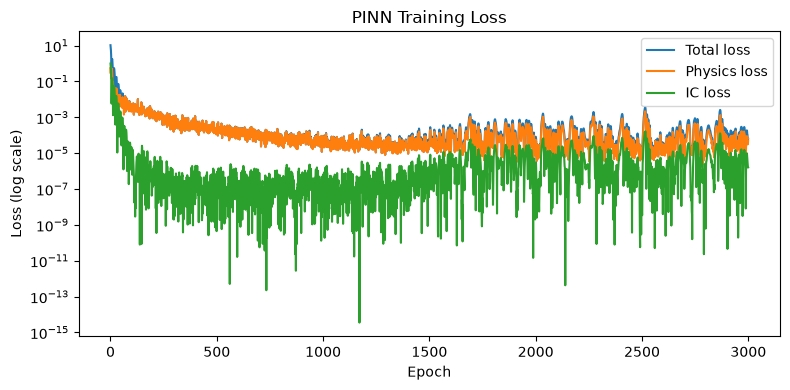

In [6]:
plt.figure(figsize=(8, 4))
plt.semilogy(loss_history, label="Total loss")
plt.semilogy(physics_history, label="Physics loss")
plt.semilogy(ic_history, label="IC loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (log scale)")
plt.title("PINN Training Loss")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Compare against the analytical solution

The PINN has never seen a single $(t, y)$ pair from $y(t) = y_0 e^{-kt}$ -- only the ODE and the initial condition. This plot is the real test of whether it learned the physics.

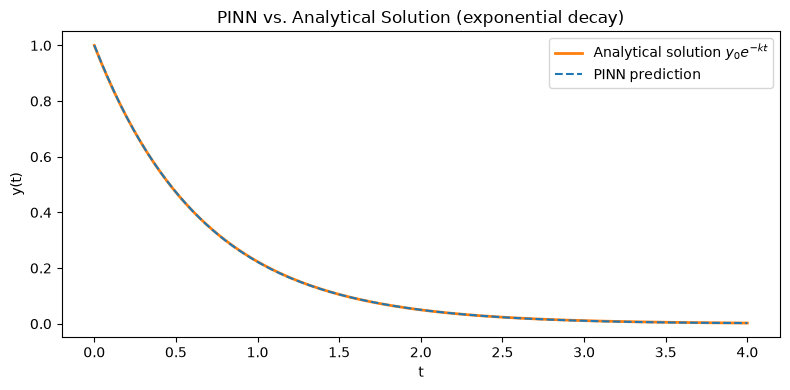

L2 error vs. analytical solution:  0.000474
Max absolute error:                0.001409


In [7]:
t_test = np.linspace(0, T, 200).reshape(-1, 1).astype(np.float32)
y_pinn = model(t_test).numpy().flatten()
y_true = analytical_solution(t_test.flatten())

plt.figure(figsize=(8, 4))
plt.plot(t_test, y_true, label="Analytical solution $y_0 e^{-kt}$", color="C1", linewidth=2)
plt.plot(t_test, y_pinn, label="PINN prediction", color="C0", linestyle="--")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.title("PINN vs. Analytical Solution (exponential decay)")
plt.legend()
plt.tight_layout()
plt.show()

l2_error = np.sqrt(np.mean((y_pinn - y_true) ** 2))
max_error = np.max(np.abs(y_pinn - y_true))
print(f"L2 error vs. analytical solution:  {l2_error:.6f}")
print(f"Max absolute error:                {max_error:.6f}")

## 6. Bonus -- inverse problem: recovering an unknown $k$

A key strength of PINNs (mentioned in the slides) is solving **inverse problems**: if $k$ is unknown but we have a few noisy measurements, we can make $k$ a trainable variable and let the data loss recover it, while the physics loss keeps the solution consistent with the (unknown) ODE structure.

C:\Users\Public\Anaconda\envs\imw2026\Lib\site-packages\keras\src\layers\layer.py:431: UserWarning: `build()` was called on layer 'pinn_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


True k:      1.5000
Recovered k: 1.5090


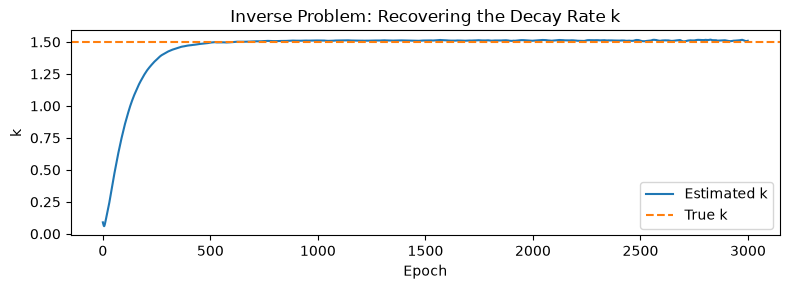

In [8]:
# A handful of noisy "measurements" of the true system (k_true is secretly 1.5, same as above)
k_true = k
t_data = np.array([0.5, 1.0, 1.5, 2.0, 2.5, 3.0], dtype=np.float32).reshape(-1, 1)
y_data = (
    analytical_solution(t_data.flatten()) + np.random.normal(0, 0.02, size=t_data.shape[0])
).astype(np.float32).reshape(-1, 1)

t_data_tf = tf.constant(t_data)
y_data_tf = tf.constant(y_data)

# A fresh network + a trainable scalar for the unknown decay rate k
inverse_model = PINN()
inverse_model.build(input_shape=(None, 1))
k_var = tf.Variable(0.1, dtype=tf.float32, trainable=True, name="k_estimate")

inverse_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-2)


@tf.function
def inverse_train_step(t_colloc):
    with tf.GradientTape() as tape:
        r = physics_residual(inverse_model, t_colloc, k_var)
        loss_physics = tf.reduce_mean(tf.square(r))

        y0_pred = inverse_model(t0)
        loss_ic = tf.reduce_mean(tf.square(y0_pred - y0_tf))

        y_data_pred = inverse_model(t_data_tf)
        loss_data = tf.reduce_mean(tf.square(y_data_pred - y_data_tf))

        loss = loss_physics + lambda_ic * loss_ic + 10.0 * loss_data

    variables = inverse_model.trainable_variables + [k_var]
    grads = tape.gradient(loss, variables)
    inverse_optimizer.apply_gradients(zip(grads, variables))
    return loss


k_history = []
for epoch in range(3000):
    t_colloc = tf.random.uniform((n_colloc, 1), minval=0.0, maxval=T, dtype=tf.float32)
    inverse_train_step(t_colloc)
    k_history.append(float(k_var))

print(f"True k:      {k_true:.4f}")
print(f"Recovered k: {float(k_var):.4f}")

plt.figure(figsize=(8, 3))
plt.plot(k_history, label="Estimated k")
plt.axhline(k_true, color="C1", linestyle="--", label="True k")
plt.xlabel("Epoch")
plt.ylabel("k")
plt.title("Inverse Problem: Recovering the Decay Rate k")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Extending to a second-order ODE: damped harmonic oscillator

The slides ("Extending to Second-Order ODEs") show that the same recipe scales to a second-order ODE:

$$m\,\frac{d^2y}{dt^2} + c\,\frac{dy}{dt} + k\,y = 0, \qquad y(0) = y_0, \qquad \dot{y}(0) = v_0.$$

Only two things change from the first-order case:
1. The residual now needs $\dfrac{d^2\hat y}{dt^2}$ -- obtained by applying automatic differentiation **twice in a row** (differentiate the derivative again).
2. There are **two** initial conditions ($y(0)=y_0$ and $\dot y(0)=v_0$), so there are two IC loss terms instead of one.

We use an **underdamped** oscillator (it oscillates while decaying), which also has a known closed-form solution to check against:

$$y(t) = e^{-\zeta t}\big(A\cos(\omega_d t) + B\sin(\omega_d t)\big), \qquad \zeta = \frac{c}{2m}, \quad \omega_d = \sqrt{\frac{k}{m} - \zeta^2}$$

with $A = y_0$ and $B = (v_0 + \zeta A)/\omega_d$ (from matching the two initial conditions).

In [9]:
# ----------------------------
# Problem definition: m*y'' + c*y' + k*y = 0, y(0)=y0_osc, y'(0)=v0_osc
# ----------------------------
m_mass = 1.0     # mass
c_damp = 0.4     # damping coefficient (small -> underdamped, oscillates while decaying)
k_spring = 4.0   # spring constant
y0_osc = 1.0     # initial position
v0_osc = 0.0     # initial velocity
T_osc = 10.0     # solve on t in [0, T_osc]

zeta = c_damp / (2 * m_mass)                       # damping ratio (per unit time)
omega_d = np.sqrt(k_spring / m_mass - zeta**2)     # damped angular frequency
A_coef = y0_osc
B_coef = (v0_osc + zeta * A_coef) / omega_d

def analytical_oscillator(t):
    """Closed-form solution of the underdamped harmonic oscillator."""
    return np.exp(-zeta * t) * (A_coef * np.cos(omega_d * t) + B_coef * np.sin(omega_d * t))

print(f"zeta (damping ratio) = {zeta:.4f}, omega_d (damped frequency) = {omega_d:.4f}")

zeta (damping ratio) = 0.2000, omega_d (damped frequency) = 1.9900


### Second-order residual: two nested `GradientTape`s

To get $\ddot{\hat y} = d^2\hat y/dt^2$, we differentiate twice: an outer tape differentiates the *result* of an inner tape's derivative. This is exactly "applying automatic differentiation twice in a row" from the slide.

In [10]:
def oscillator_derivatives(model, t):
    """Return (y_hat, dy/dt, d2y/dt2) at the given points t, via nested autodiff."""
    with tf.GradientTape() as tape2:
        tape2.watch(t)
        with tf.GradientTape() as tape1:
            tape1.watch(t)
            y_hat = model(t)
        dy_dt = tape1.gradient(y_hat, t)   # first derivative (inner tape)
    d2y_dt2 = tape2.gradient(dy_dt, t)     # second derivative (outer tape, applied to dy_dt)
    return y_hat, dy_dt, d2y_dt2


def oscillator_residual(model, t, m, c, k):
    """Physics residual r(t) = m*y'' + c*y' + k*y for the damped oscillator."""
    y_hat, dy_dt, d2y_dt2 = oscillator_derivatives(model, t)
    return m * d2y_dt2 + c * dy_dt + k * y_hat

### Loss with two initial conditions, and the training loop

$$\mathcal{L}(\theta) = \mathcal{L}_{\text{physics}} + \lambda\big(\underbrace{(\hat y(0)-y_0)^2}_{\text{position IC}} + \underbrace{(\dot{\hat y}(0)-v_0)^2}_{\text{velocity IC}}\big)$$

Nothing else changes: same collocation-point resampling, same Adam optimizer, same nested-autodiff training pattern as the first-order example.

In [11]:
osc_model = PINN(hidden_units=(32, 32, 32))
osc_model.build(input_shape=(None, 1))

# Learning-rate decay helps convergence here: the oscillatory target over a
# longer domain (T=10) is harder to fit than the monotonic decay case, so a
# smaller step size later in training reduces residual "jitter" around the minimum.
osc_lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=1e-2, decay_steps=2000, decay_rate=0.5
)
osc_optimizer = tf.keras.optimizers.Adam(learning_rate=osc_lr_schedule)
lambda_ic_osc = 10.0
t0_osc = tf.constant([[0.0]], dtype=tf.float32)
y0_osc_tf = tf.constant([[y0_osc]], dtype=tf.float32)
v0_osc_tf = tf.constant([[v0_osc]], dtype=tf.float32)


@tf.function
def osc_train_step(t_colloc):
    with tf.GradientTape() as tape:  # outer-most tape: d(loss)/d(theta)
        r = oscillator_residual(osc_model, t_colloc, m_mass, c_damp, k_spring)
        loss_physics = tf.reduce_mean(tf.square(r))

        # Initial conditions: position AND velocity at t=0
        _, dy0_dt, _ = oscillator_derivatives(osc_model, t0_osc)
        y0_pred = osc_model(t0_osc)
        loss_ic_pos = tf.reduce_mean(tf.square(y0_pred - y0_osc_tf))
        loss_ic_vel = tf.reduce_mean(tf.square(dy0_dt - v0_osc_tf))
        loss_ic = loss_ic_pos + loss_ic_vel

        loss = loss_physics + lambda_ic_osc * loss_ic

    grads = tape.gradient(loss, osc_model.trainable_variables)
    osc_optimizer.apply_gradients(zip(grads, osc_model.trainable_variables))
    return loss, loss_physics, loss_ic


n_colloc_osc = 128
epochs_osc = 10000
osc_loss_history = []

for epoch in range(epochs_osc):
    t_colloc = tf.random.uniform((n_colloc_osc, 1), minval=0.0, maxval=T_osc, dtype=tf.float32)
    loss, loss_physics, loss_ic = osc_train_step(t_colloc)
    osc_loss_history.append(float(loss))

    if (epoch + 1) % 1000 == 0:
        print(
            f"Epoch {epoch+1:5d}/{epochs_osc}  "
            f"loss={loss:.6f}  physics={loss_physics:.6f}  ic={loss_ic:.6f}"
        )

C:\Users\Public\Anaconda\envs\imw2026\Lib\site-packages\keras\src\layers\layer.py:431: UserWarning: `build()` was called on layer 'pinn_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Epoch  1000/10000  loss=0.069286  physics=0.066091  ic=0.000319


Epoch  2000/10000  loss=0.029883  physics=0.024699  ic=0.000518


Epoch  3000/10000  loss=0.024819  physics=0.024471  ic=0.000035


Epoch  4000/10000  loss=0.016503  physics=0.015606  ic=0.000090


...

Epoch  6000/10000  loss=0.013703  physics=0.011935  ic=0.000177


Epoch  7000/10000  loss=0.009291  physics=0.009250  ic=0.000004


Epoch  8000/10000  loss=0.009739  physics=0.009658  ic=0.000008


Epoch  9000/10000  loss=0.008836  physics=0.008714  ic=0.000012


Epoch 10000/10000  loss=0.008803  physics=0.008663  ic=0.000014


### Results: training loss and PINN vs. analytical solution

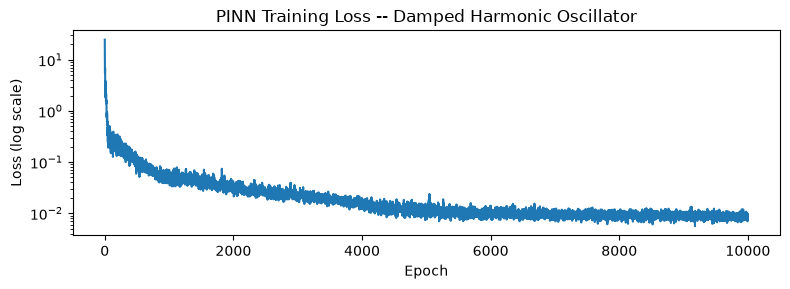

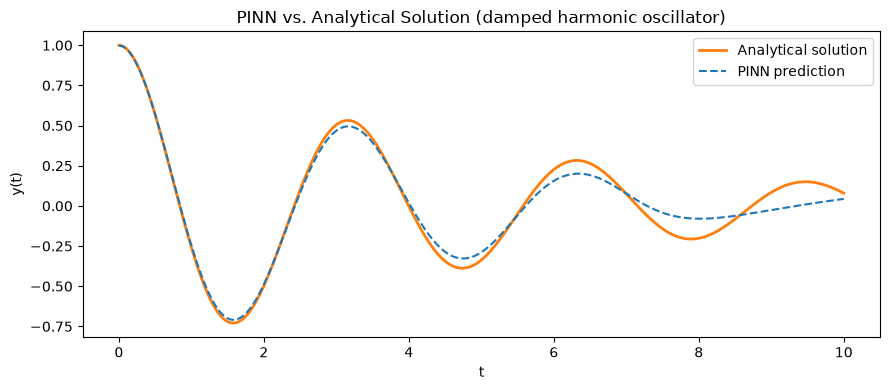

L2 error vs. analytical solution:  0.062277
Max absolute error:                0.145437


In [12]:
plt.figure(figsize=(8, 3))
plt.semilogy(osc_loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss (log scale)")
plt.title("PINN Training Loss -- Damped Harmonic Oscillator")
plt.tight_layout()
plt.show()

t_test_osc = np.linspace(0, T_osc, 300).reshape(-1, 1).astype(np.float32)
y_pinn_osc = osc_model(t_test_osc).numpy().flatten()
y_true_osc = analytical_oscillator(t_test_osc.flatten())

plt.figure(figsize=(9, 4))
plt.plot(t_test_osc, y_true_osc, label="Analytical solution", color="C1", linewidth=2)
plt.plot(t_test_osc, y_pinn_osc, label="PINN prediction", color="C0", linestyle="--")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.title("PINN vs. Analytical Solution (damped harmonic oscillator)")
plt.legend()
plt.tight_layout()
plt.show()

l2_error_osc = np.sqrt(np.mean((y_pinn_osc - y_true_osc) ** 2))
max_error_osc = np.max(np.abs(y_pinn_osc - y_true_osc))
print(f"L2 error vs. analytical solution:  {l2_error_osc:.6f}")
print(f"Max absolute error:                {max_error_osc:.6f}")